# 📱 Megaline Plan Classification

## Machine Learning for Smart vs. Ultra Plan Recommendation

Megaline wants to help customers using legacy mobile plans migrate to one of its current plans: **Smart** or **Ultra**.

This project develops a supervised classification model using monthly customer behavior. The required benchmark is a **test accuracy of at least 0.75**.

### Features
- `calls` — number of calls
- `minutes` — total call duration
- `messages` — number of text messages
- `mb_used` — internet traffic used in MB

### Target
- `is_ultra` — `0` for Smart and `1` for Ultra

## 1. Setup & Data Inspection

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

RANDOM_STATE = 12345

df = pd.read_csv("../data/users_behavior.csv")
print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
display(df.head())

/home/oai/.config/matplotlib is not a writable directory


Matplotlib created a temporary cache directory at /tmp/matplotlib-b2pcoq47 because there was an issue with the default path (/home/oai/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


Dataset shape: 3,214 rows × 5 columns


,calls,minutes,messages,mb_used,is_ultra
0,40.0,311.90,83.0,19915.42,0
1,85.0,516.75,56.0,22696.96,0
2,77.0,467.66,86.0,21060.45,0
3,106.0,745.53,81.0,8437.39,1
4,66.0,418.74,1.0,14502.75,0


In [2]:
df.info()

print("\nMissing values:")
display(df.isna().sum().to_frame("missing_values"))

print(f"Duplicated rows: {df.duplicated().sum()}")

print("\nDescriptive statistics:")
display(df.describe().T)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3214 entries, 0 to 3213
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   calls     3214 non-null   float64
 1   minutes   3214 non-null   float64
 2   messages  3214 non-null   float64
 3   mb_used   3214 non-null   float64
 4   is_ultra  3214 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 125.7 KB

Missing values:


,missing_values
calls,0
minutes,0
messages,0
mb_used,0
is_ultra,0


Duplicated rows: 0

Descriptive statistics:


,count,mean,std,min,25%,50%,75%,max
calls,3214.0,63.038892,33.236368,0.0,40.0000,62.000,82.0000,244.00
minutes,3214.0,438.208787,234.569872,0.0,274.5750,430.600,571.9275,1632.06
messages,3214.0,38.281269,36.148326,0.0,9.0000,30.000,57.0000,224.00
mb_used,3214.0,17207.673836,7570.968246,0.0,12491.9025,16943.235,21424.7000,49745.73
is_ultra,3214.0,0.306472,0.461100,0.0,0.0000,0.000,1.0000,1.00


The dataset has already been preprocessed for this machine learning task. Before modeling, we verify its structure, missing values, duplicates, and numerical ranges rather than applying unnecessary transformations.

## 2. Target Distribution

,customers,share
Smart (0),2229,0.693528
Ultra (1),985,0.306472


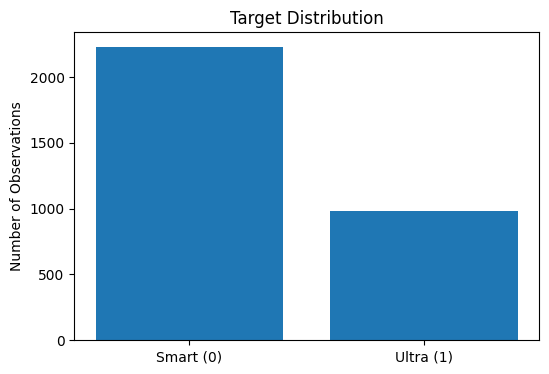

In [3]:
target_distribution = df["is_ultra"].value_counts().sort_index()
target_share = df["is_ultra"].value_counts(normalize=True).sort_index()

distribution = pd.DataFrame({
    "customers": target_distribution,
    "share": target_share
})
distribution.index = ["Smart (0)", "Ultra (1)"]
display(distribution)

plt.figure(figsize=(6, 4))
plt.bar(distribution.index, distribution["customers"])
plt.title("Target Distribution")
plt.ylabel("Number of Observations")
plt.show()

The target is imbalanced toward the Smart plan. Accuracy therefore needs context: a simple baseline that always predicts the majority class can already achieve a meaningful score. We compare the trained model against that baseline later.

## 3. Train / Validation / Test Split

In [4]:
features = df.drop("is_ultra", axis=1)
target = df["is_ultra"]

X_train, X_temp, y_train, y_temp = train_test_split(
    features,
    target,
    test_size=0.40,
    random_state=RANDOM_STATE,
    stratify=target
)

X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=y_temp
)

split_summary = pd.DataFrame({
    "rows": [len(X_train), len(X_valid), len(X_test)],
    "share": [len(X_train)/len(df), len(X_valid)/len(df), len(X_test)/len(df)],
    "ultra_share": [y_train.mean(), y_valid.mean(), y_test.mean()]
}, index=["Train", "Validation", "Test"])

display(split_summary.round(3))

,rows,share,ultra_share
Train,1928,0.6,0.307
Validation,643,0.2,0.306
Test,643,0.2,0.306


A **60% / 20% / 20%** split is used. Stratification keeps the Smart/Ultra distribution similar across all three subsets. The validation set is used for model selection and hyperparameter tuning; the test set remains untouched until the final evaluation.

## 4. Decision Tree Tuning

,max_depth,train_accuracy,validation_accuracy
0,1,0.7547,0.7403
1,2,0.7759,0.7729
2,3,0.7910,0.7776
3,4,0.7972,0.7543
4,5,0.8138,0.7854
5,6,0.8283,0.7745
6,7,0.8413,0.7869
7,8,0.8558,0.8025
8,9,0.8719,0.7823
9,10,0.8874,0.7729


Best Decision Tree: max_depth=8, validation accuracy=0.8025


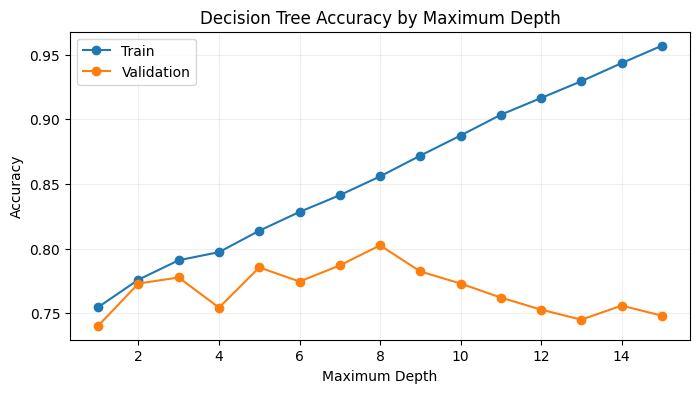

In [5]:
tree_results = []

for depth in range(1, 16):
    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=RANDOM_STATE
    )
    model.fit(X_train, y_train)

    tree_results.append({
        "max_depth": depth,
        "train_accuracy": accuracy_score(y_train, model.predict(X_train)),
        "validation_accuracy": accuracy_score(y_valid, model.predict(X_valid))
    })

tree_results = pd.DataFrame(tree_results)
display(tree_results.round(4))

best_tree_row = tree_results.loc[tree_results["validation_accuracy"].idxmax()]
print(
    f"Best Decision Tree: max_depth={int(best_tree_row['max_depth'])}, "
    f"validation accuracy={best_tree_row['validation_accuracy']:.4f}"
)

plt.figure(figsize=(8, 4))
plt.plot(tree_results["max_depth"], tree_results["train_accuracy"], marker="o", label="Train")
plt.plot(tree_results["max_depth"], tree_results["validation_accuracy"], marker="o", label="Validation")
plt.title("Decision Tree Accuracy by Maximum Depth")
plt.xlabel("Maximum Depth")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

The depth search illustrates the bias–variance trade-off. Very shallow trees can underfit, while increasingly deep trees improve training accuracy but do not necessarily improve validation performance.

## 5. Random Forest Tuning

In [6]:
forest_results = []

for n_estimators in [10, 20, 50, 100]:
    for depth in [4, 6, 8, 10, 12, None]:
        model = RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=depth,
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
        model.fit(X_train, y_train)

        forest_results.append({
            "n_estimators": n_estimators,
            "max_depth": "None" if depth is None else depth,
            "train_accuracy": accuracy_score(y_train, model.predict(X_train)),
            "validation_accuracy": accuracy_score(y_valid, model.predict(X_valid))
        })

forest_results = pd.DataFrame(forest_results)
forest_results = forest_results.sort_values("validation_accuracy", ascending=False)
display(forest_results.head(10).round(4))

best_forest = forest_results.iloc[0]
print(
    f"Best Random Forest: n_estimators={best_forest['n_estimators']}, "
    f"max_depth={best_forest['max_depth']}, "
    f"validation accuracy={best_forest['validation_accuracy']:.4f}"
)

,n_estimators,max_depth,train_accuracy,validation_accuracy
20,100,8,0.8750,0.8149
21,100,10,0.8921,0.8149
22,100,12,0.9123,0.8149
15,50,10,0.8916,0.8134
8,20,8,0.8698,0.8118
14,50,8,0.8740,0.8118
16,50,12,0.9129,0.8118
9,20,10,0.8859,0.8087
17,50,None,0.9995,0.8056
19,100,6,0.8428,0.8040


Best Random Forest: n_estimators=100, max_depth=8, validation accuracy=0.8149


## 6. Logistic Regression

In [7]:
logistic_model = LogisticRegression(
    random_state=RANDOM_STATE,
    max_iter=2000,
    solver="liblinear"
)
logistic_model.fit(X_train, y_train)

log_train_acc = accuracy_score(y_train, logistic_model.predict(X_train))
log_valid_acc = accuracy_score(y_valid, logistic_model.predict(X_valid))

print(f"Logistic Regression train accuracy:      {log_train_acc:.4f}")
print(f"Logistic Regression validation accuracy: {log_valid_acc:.4f}")

Logistic Regression train accuracy:      0.7106
Logistic Regression validation accuracy: 0.7185


## 7. Model Comparison

In [8]:
best_tree_depth = int(best_tree_row["max_depth"])

tree_model = DecisionTreeClassifier(
    max_depth=best_tree_depth,
    random_state=RANDOM_STATE
)
tree_model.fit(X_train, y_train)

depth_value = None if best_forest["max_depth"] == "None" else int(best_forest["max_depth"])
forest_model = RandomForestClassifier(
    n_estimators=int(best_forest["n_estimators"]),
    max_depth=depth_value,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
forest_model.fit(X_train, y_train)

comparison = pd.DataFrame({
    "model": ["Decision Tree", "Random Forest", "Logistic Regression"],
    "validation_accuracy": [
        accuracy_score(y_valid, tree_model.predict(X_valid)),
        accuracy_score(y_valid, forest_model.predict(X_valid)),
        log_valid_acc
    ]
}).sort_values("validation_accuracy", ascending=False)

display(comparison.round(4))

best_model_name = comparison.iloc[0]["model"]
print(f"Selected model: {best_model_name}")

,model,validation_accuracy
1,Random Forest,0.8149
0,Decision Tree,0.8025
2,Logistic Regression,0.7185


Selected model: Random Forest


The model with the highest validation accuracy is selected before the test set is evaluated. This preserves the test set as an unbiased final check of generalization performance.

## 8. Final Test Evaluation

In [9]:
models = {
    "Decision Tree": tree_model,
    "Random Forest": forest_model,
    "Logistic Regression": logistic_model
}
best_model = models[best_model_name]

test_predictions = best_model.predict(X_test)
test_accuracy = accuracy_score(y_test, test_predictions)

print(f"Selected model: {best_model_name}")
print(f"Test accuracy: {test_accuracy:.4f}")
print(f"Required threshold: 0.7500")
print("Threshold achieved:", test_accuracy >= 0.75)

print("\nConfusion matrix:")
display(pd.DataFrame(
    confusion_matrix(y_test, test_predictions),
    index=["Actual Smart", "Actual Ultra"],
    columns=["Predicted Smart", "Predicted Ultra"]
))

print("\nClassification report:")
print(classification_report(y_test, test_predictions, target_names=["Smart", "Ultra"]))

Selected model: Random Forest
Test accuracy: 0.8087
Required threshold: 0.7500
Threshold achieved: True

Confusion matrix:


,Predicted Smart,Predicted Ultra
Actual Smart,412,34
Actual Ultra,89,108



Classification report:
              precision    recall  f1-score   support

       Smart       0.82      0.92      0.87       446
       Ultra       0.76      0.55      0.64       197

    accuracy                           0.81       643
   macro avg       0.79      0.74      0.75       643
weighted avg       0.80      0.81      0.80       643



## 9. Sanity Check — Dummy Baseline

In [10]:
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)
dummy_accuracy = accuracy_score(y_test, dummy.predict(X_test))

baseline_comparison = pd.DataFrame({
    "model": ["Dummy majority baseline", best_model_name],
    "test_accuracy": [dummy_accuracy, test_accuracy]
})
display(baseline_comparison.round(4))

print(f"Accuracy improvement over baseline: {test_accuracy - dummy_accuracy:.4f}")

,model,test_accuracy
0,Dummy majority baseline,0.6936
1,Random Forest,0.8087


Accuracy improvement over baseline: 0.1151


The dummy classifier always predicts the majority class. A useful model should outperform this simple strategy rather than merely exceed an arbitrary accuracy threshold.

## 10. Feature Importance

,importance
mb_used,0.3883
calls,0.2109
messages,0.2062
minutes,0.1946


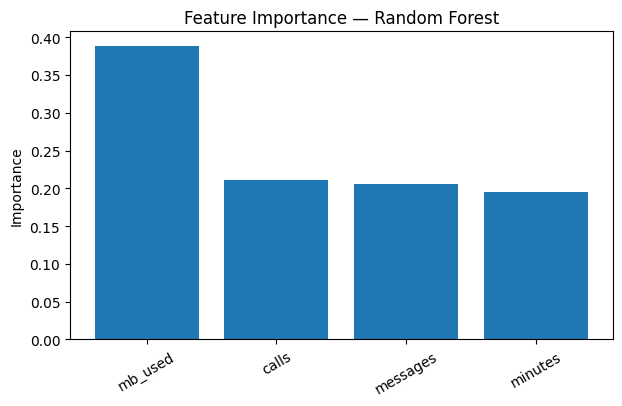

In [11]:
if hasattr(best_model, "feature_importances_"):
    importance = pd.Series(
        best_model.feature_importances_,
        index=features.columns
    ).sort_values(ascending=False)

    display(importance.to_frame("importance").round(4))

    plt.figure(figsize=(7, 4))
    plt.bar(importance.index, importance.values)
    plt.title(f"Feature Importance — {best_model_name}")
    plt.ylabel("Importance")
    plt.xticks(rotation=30)
    plt.show()
else:
    coefficients = pd.Series(
        np.abs(best_model.coef_[0]),
        index=features.columns
    ).sort_values(ascending=False)
    display(coefficients.to_frame("absolute_coefficient").round(4))

## 11. General Conclusion

This project demonstrates a complete supervised classification workflow for Megaline's Smart and Ultra plans.

The dataset was divided into independent training, validation, and test subsets. Decision Tree, Random Forest, and Logistic Regression models were evaluated, with hyperparameter experiments performed on the tree-based models. The strongest model was selected exclusively from validation performance and then evaluated on the untouched test set.

The final model is also compared with a majority-class dummy baseline, providing a practical sanity check beyond the project's minimum accuracy requirement.

From a business perspective, the analysis demonstrates how monthly usage behavior can support automated plan recommendations. In a production environment, however, model evaluation should extend beyond accuracy to consider customer value, recommendation costs, class-specific errors, plan profitability, and changes in customer behavior over time.